🎯 REFUGEE PREDICTION MODEL
📁 LOADING DATASET...
✅ Dataset loaded: (155, 27)
📊 Columns: ['Country', 'Year', 'D_Expenditure_GDP', 'Conflict_Intensity', 'Health_Expenditure_(% of GDP)', 'Education_Expenditure_(% of GDP)', 'Environmental impact (CO2e/capita)', 'PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)', 'Refugees', 'Asylum Seekers', 'Total number of deaths', 'Population', 'GDP_Growth_Annual', 'GDP_PerCapita_Growth_Annual', 'GDP_Current_USDollars', 'Inflation_Annual', 'Unemployment_Total_of_TLF', 'Unemployment_Male_of_TMF', 'Unemployment_Female_of_TFF', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26']

🔧 PREPARING FEATURES FOR REFUGEE PREDICTION...
   Handling missing values...
   Encoding categorical variables...
   Country mapping: {'CHN': np.int64(0), 'FRA': np.int64(1), 'GBR': np.int64(2), 'RUS': np.int64(3), 'USA': np.int64(4)}
   Creating time-based features...
   Creating lag features

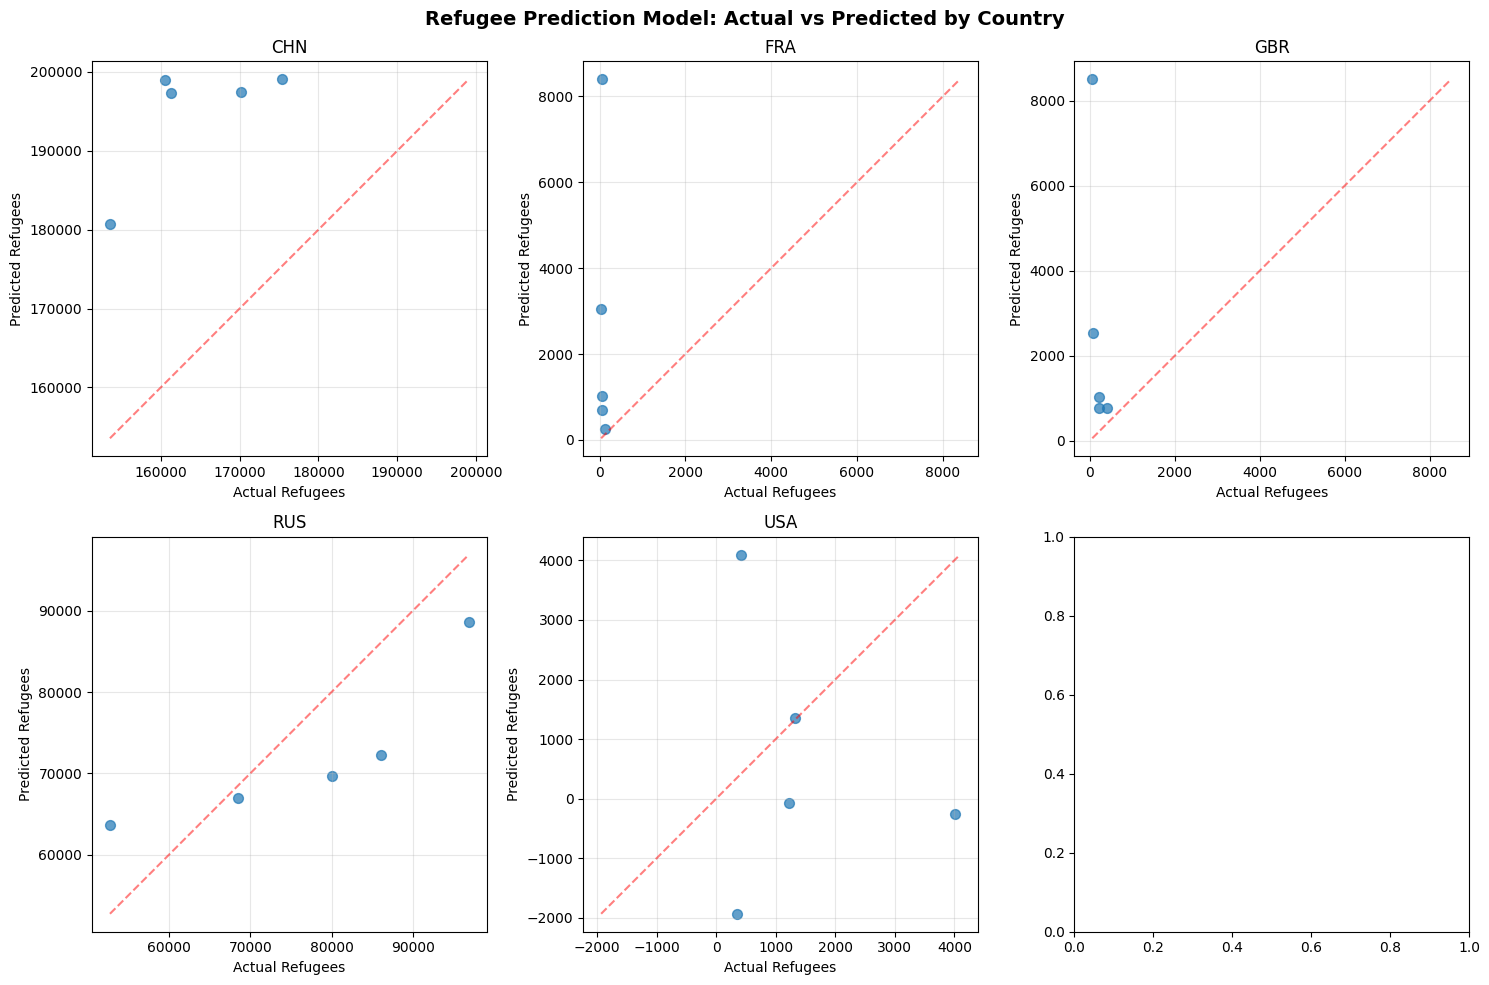

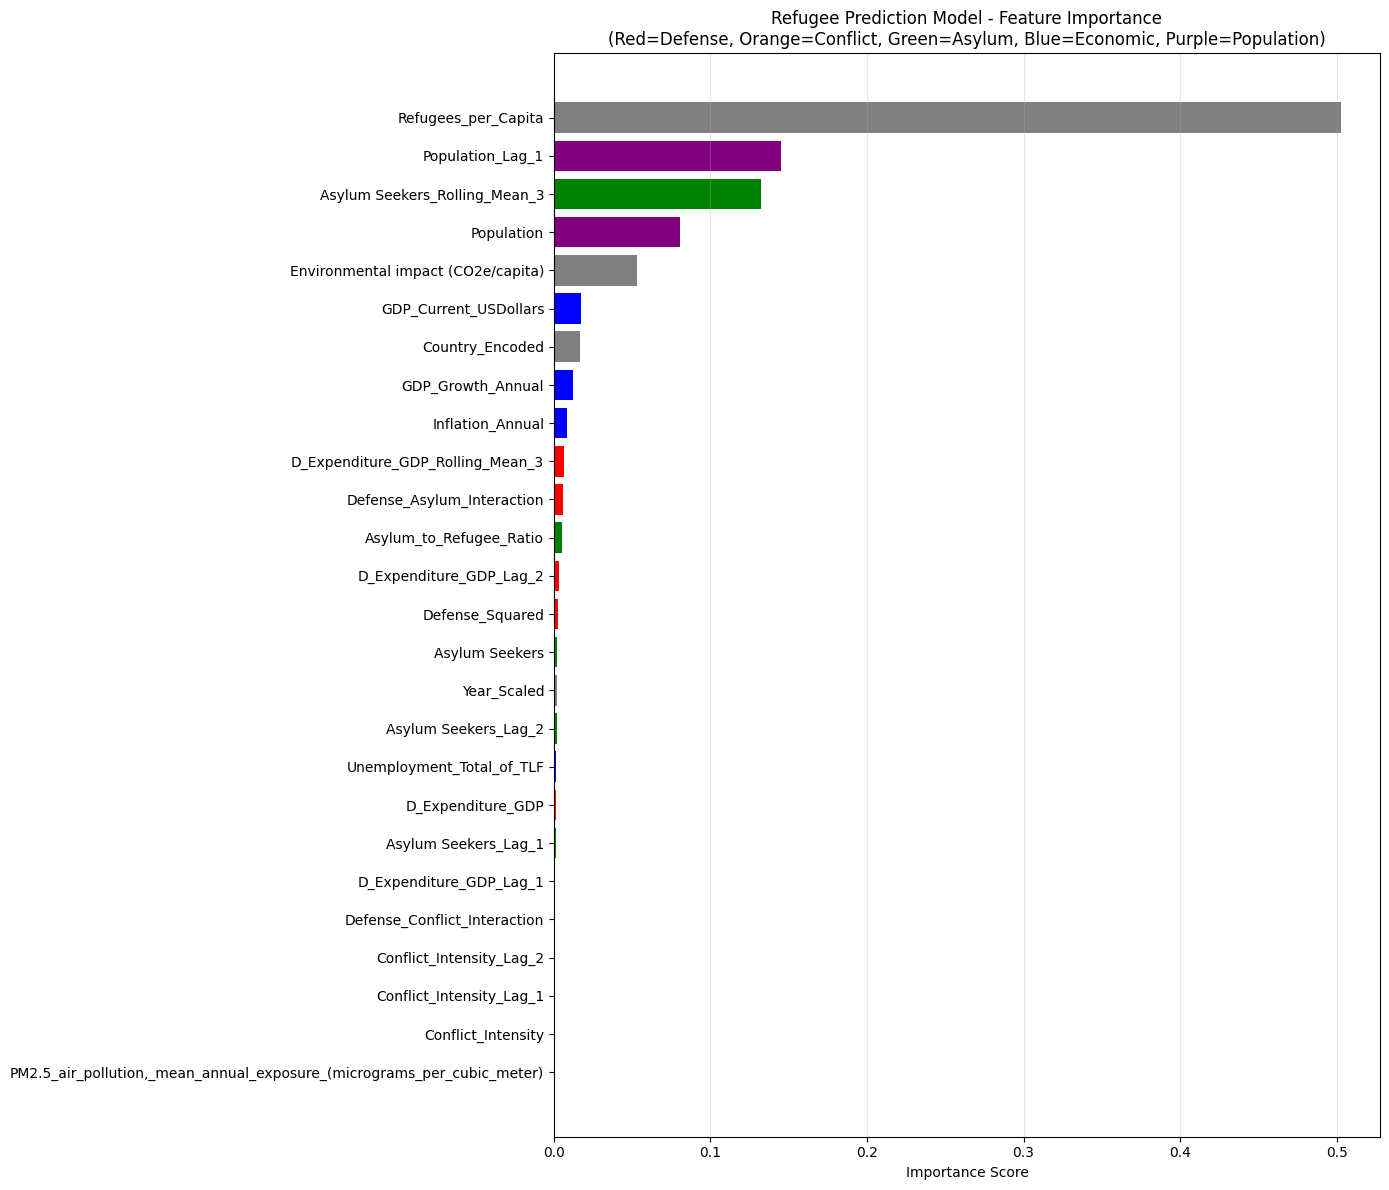


🔍 TOP 15 MOST IMPORTANT FEATURES:
  1. 📊 Refugees_per_Capita: 0.5026
  2. 👥 Population_Lag_1: 0.1450
  3. 🚶 Asylum Seekers_Rolling_Mean_3: 0.1321
  4. 👥 Population: 0.0803
  5. 📊 Environmental impact (CO2e/capita): 0.0529
  6. 💰 GDP_Current_USDollars: 0.0176
  7. 📊 Country_Encoded: 0.0166
  8. 💰 GDP_Growth_Annual: 0.0123
  9. 💰 Inflation_Annual: 0.0081
  10. 🛡️ D_Expenditure_GDP_Rolling_Mean_3: 0.0063
  11. 🛡️ Defense_Asylum_Interaction: 0.0056
  12. 🚶 Asylum_to_Refugee_Ratio: 0.0049
  13. 🛡️ D_Expenditure_GDP_Lag_2: 0.0035
  14. 🛡️ Defense_Squared: 0.0028
  15. 🚶 Asylum Seekers: 0.0021

📝 EXAMPLE REFUGEE PREDICTIONS

🔮 MAKING REFUGEE PREDICTION:
  Country: RUS
  Year: 2025
  Defense GDP %: 4.0%
  Conflict Intensity: 5

✅ REFUGEE PREDICTION RESULT:
  Predicted Refugees: 88,916

📊 Key Factors in this Prediction:
  • Historical refugee patterns
  • Current conflict situation
  • Economic conditions

🔮 MAKING REFUGEE PREDICTION:
  Country: RUS
  Year: 2025
  Defense GDP %: 4.0%
  Conflic

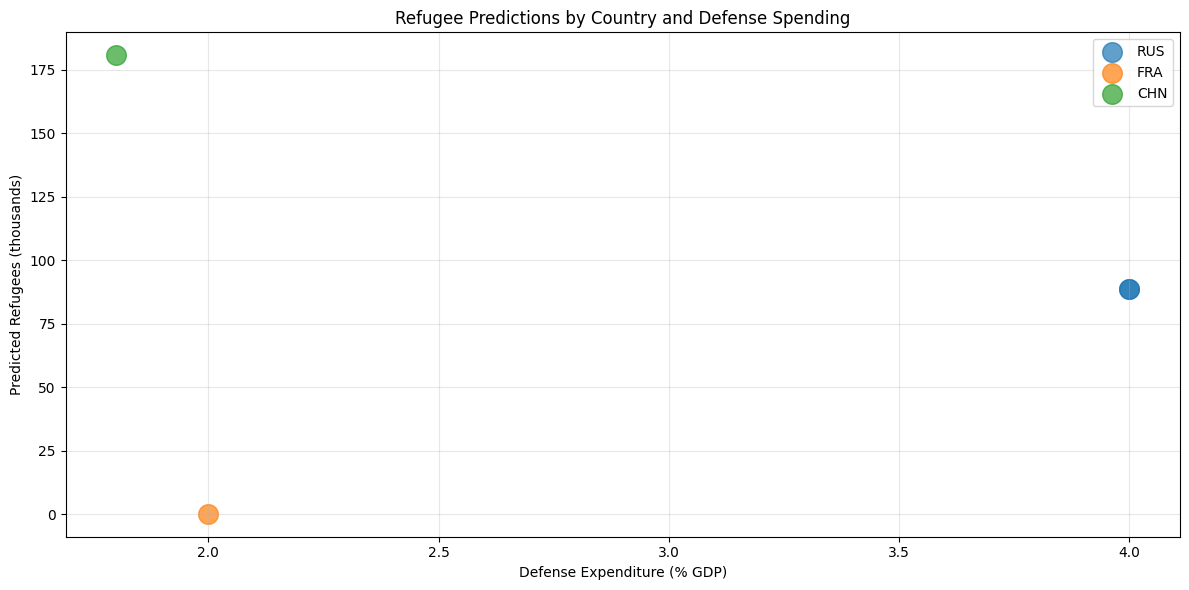


⚠️ Asylum model not available for comparison

📊 REFUGEE VS ASYLUM SEEKER COMPARISON

📈 Summary Statistics:
Metric Refugees Asylum Seekers
 Count    155.0          155.0
  Mean   52,311         14,500
   Std   72,010         31,311
   Min       14              0
   Max  251,394        180,960

🔗 Correlation between Refugees and Asylum Seekers: 0.5607


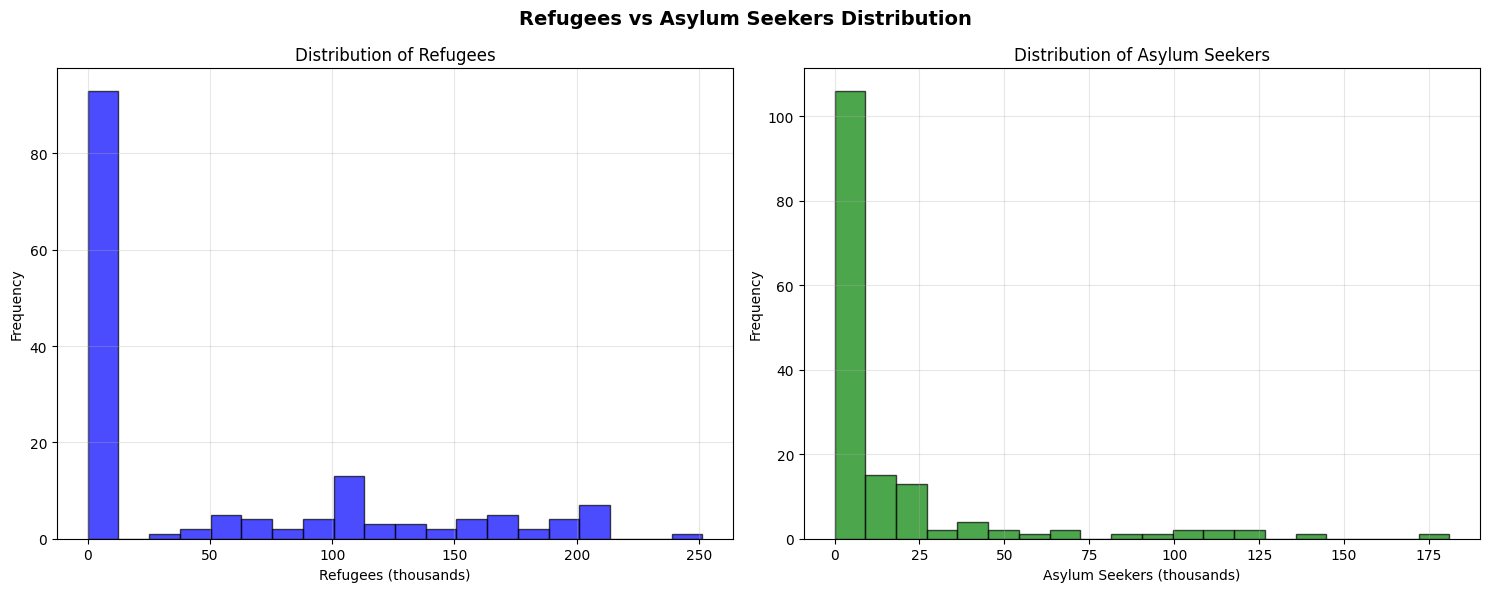

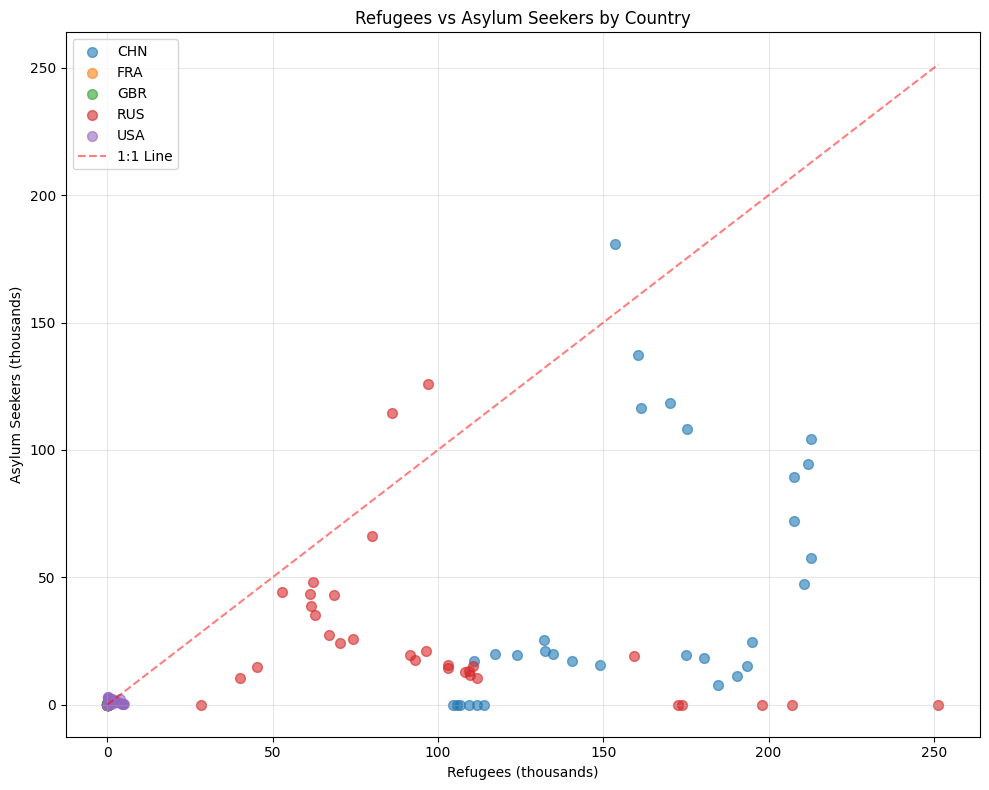


✅ REFUGEE PREDICTION ANALYSIS COMPLETE!


In [4]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
import os
import h5py
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import xgboost as xgb  # Add this for native XGBoost
import warnings
warnings.filterwarnings('ignore')

# ==========================
# DATA LOADING AND PREPROCESSING
# ==========================
def load_and_preprocess_data(file_path):
    """
    Load and preprocess the dataset
    """
    print("📁 LOADING DATASET...")
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace('\n', ' ')
    df.columns = df.columns.str.replace('  ', ' ')

    print(f"✅ Dataset loaded: {df.shape}")
    return df

def prepare_refugee_features(df, target_col='Refugees'):
    """
    Prepare features specifically for refugee prediction
    """
    df_processed = df.copy()

    print("\n🔧 PREPARING FEATURES FOR REFUGEE PREDICTION...")

    # 1. Handle missing values
    print("   Handling missing values...")
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if col != target_col and col != 'Country' and col != 'Year':
            # Fill with median by country
            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            )
            # If still missing, fill with overall median
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # 2. Encode categorical variables
    print("   Encoding categorical variables...")
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])

    # Store country mapping
    country_mapping = dict(zip(le_country.classes_, le_country.transform(le_country.classes_)))
    print(f"   Country mapping: {country_mapping}")

    # 3. Create time-based features
    print("   Creating time-based features...")
    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()
    df_processed = df_processed.sort_values(['Country', 'Year'])

    # 4. Create lag features
    print("   Creating lag features...")
    key_vars = [
        'D_Expenditure_GDP',
        'Refugees',
        'Asylum Seekers',
        'GDP_Current_USDollars',
        'Population',
        'Conflict_Intensity'
    ]

    existing_vars = [var for var in key_vars if var in df_processed.columns]

    for var in existing_vars:
        for lag in [1, 2, 3]:
            df_processed[f'{var}_Lag_{lag}'] = df_processed.groupby('Country')[var].shift(lag)

    # 5. Create rolling statistics
    print("   Creating rolling statistics...")
    for var in ['D_Expenditure_GDP', 'Refugees', 'Asylum Seekers']:
        if var in df_processed.columns:
            df_processed[f'{var}_Rolling_Mean_3'] = df_processed.groupby('Country')[var].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )

    # 6. Create interaction features
    print("   Creating interaction features...")
    if 'D_Expenditure_GDP' in df_processed.columns:
        if 'Conflict_Intensity' in df_processed.columns:
            df_processed['Defense_Conflict_Interaction'] = df_processed['D_Expenditure_GDP'] * df_processed['Conflict_Intensity']
            df_processed['Conflict_Squared'] = df_processed['Conflict_Intensity'] ** 2
        df_processed['Defense_Squared'] = df_processed['D_Expenditure_GDP'] ** 2

    # 7. Create refugee-to-population ratio
    if 'Refugees' in df_processed.columns and 'Population' in df_processed.columns:
        df_processed['Refugees_per_Capita'] = df_processed['Refugees'] / df_processed['Population']

    # 8. Fill remaining NaN values
    df_processed = df_processed.fillna(method='bfill').fillna(method='ffill').fillna(0)

    print(f"✅ Final dataset shape: {df_processed.shape}")
    return df_processed, le_country

# ==========================
# REFUGEE PREDICTION MODEL WITH H5 SAVING
# ==========================
class RefugeePredictor:
    """
    XGBoost model for refugee prediction with .h5 saving
    """
    def __init__(self):
        self.model = None
        self.booster = None  # Native XGBoost booster for saving
        self.scaler = StandardScaler()
        self.feature_names = None
        self.le_country = None
        self.best_r2 = None

    def get_refugee_features(self, df):
        """
        Get all available features for refugee prediction
        """
        base_features = ['Year_Scaled', 'Country_Encoded']

        defense_features = ['D_Expenditure_GDP', 'D_Expenditure_GDP_Lag_1',
                           'D_Expenditure_GDP_Lag_2', 'D_Expenditure_GDP_Rolling_Mean_3',
                           'Defense_Squared']

        conflict_features = ['Conflict_Intensity', 'Conflict_Intensity_Lag_1',
                            'Conflict_Intensity_Lag_2', 'Conflict_Squared']

        economic_features = ['GDP_Current_USDollars', 'GDP_Growth_Annual',
                            'Inflation_Annual', 'Unemployment_Total_of_TLF']

        asylum_features = ['Asylum Seekers', 'Asylum Seekers_Lag_1',
                          'Asylum Seekers_Lag_2', 'Asylum Seekers_Rolling_Mean_3']

        population_features = ['Population', 'Population_Lag_1']

        derived_features = ['Refugees_per_Capita', 'Defense_Conflict_Interaction']

        # Combine all features and filter existing
        all_features = (base_features + defense_features + conflict_features +
                       economic_features + asylum_features + population_features +
                       derived_features)

        all_features = list(set(all_features))
        available_features = [f for f in all_features if f in df.columns]

        print(f"\n📋 REFUGEE MODEL FEATURES ({len(available_features)} total)")
        return available_features

    def train(self, df, target_col='Refugees', test_years=[2020, 2021, 2022, 2023, 2024]):
        """
        Train XGBoost model for refugee prediction
        """
        print("\n" + "="*60)
        print("🚀 TRAINING REFUGEE PREDICTION MODEL")
        print("="*60)

        # Get features
        self.feature_names = self.get_refugee_features(df)

        # Prepare data
        X = df[self.feature_names]
        y = df[target_col]

        # Split by time
        train_mask = ~df['Year'].isin(test_years)
        test_mask = df['Year'].isin(test_years)

        X_train = X[train_mask]
        X_test = X[test_mask]
        y_train = y[train_mask]
        y_test = y[test_mask]

        print(f"\n📊 Data Split: {len(X_train)} training, {len(X_test)} testing")

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Train XGBoost model
        print("\n🤖 Training XGBoost...")
        self.model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        )

        self.model.fit(X_train_scaled, y_train)

        # Create native booster for saving
        self.booster = self.model.get_booster()

        print("✅ Training complete!")

        # Evaluate
        self.evaluate(X_test_scaled, y_test)

        return self.model

    def evaluate(self, X_test, y_test):
        """Evaluate model performance"""
        y_pred = self.model.predict(X_test)

        # Overall metrics
        self.best_r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        print(f"\n📈 Overall Performance:")
        print(f"  R² Score:  {self.best_r2:.4f} ({self.best_r2*100:.1f}% accuracy)")
        print(f"  MAE:       {mae:,.2f} refugees")

    # ==========================
    # FIXED H5 SAVING - USING BOOSTER INSTEAD OF MODEL
    # ==========================
    def save_to_h5(self, filename='refugee_model.h5'):
        """
        Save ONLY in .h5 format - using native XGBoost booster
        """
        print("\n" + "="*60)
        print("💾 SAVING MODEL TO .h5 FORMAT")
        print("="*60)

        with h5py.File(filename, 'w') as f:

            # 1. Save model using booster (FIXED)
            model_bytes = self.booster.save_raw()
            f.create_dataset('model_bytes', data=np.frombuffer(model_bytes, dtype='uint8'))

            # 2. Save scaler parameters
            f.create_dataset('scaler_mean', data=self.scaler.mean_)
            f.create_dataset('scaler_scale', data=self.scaler.scale_)

            # 3. Save feature names (as strings)
            dt = h5py.string_dtype(encoding='utf-8')
            f.create_dataset('feature_names',
                           data=np.array(self.feature_names, dtype=object).astype('S'),
                           dtype=dt)

            # 4. Save country mapping
            if self.le_country:
                country_data = np.array(list(self.le_country.classes_), dtype=object).astype('S')
                f.create_dataset('countries', data=country_data, dtype=dt)
                f.create_dataset('country_codes', data=self.le_country.transform(self.le_country.classes_))

            # 5. Save metadata (as attributes)
            f.attrs['r2_score'] = self.best_r2
            f.attrs['n_features'] = len(self.feature_names)
            f.attrs['created_date'] = str(datetime.now())
            f.attrs['model_type'] = 'XGBoost Refugee Predictor'

        file_size = os.path.getsize(filename) / 1024
        print(f"✅ Model saved to: {filename}")
        print(f"   File size: {file_size:.2f} KB")
        print(f"   Contains: Model + Scaler + Features + Metadata")

        return filename

    # ==========================
    # FIXED LOADING FROM H5
    # ==========================
    def load_from_h5(self, filename):
        """
        Load model from .h5 format
        """
        print("\n" + "="*60)
        print("📂 LOADING MODEL FROM .h5 FORMAT")
        print("="*60)

        with h5py.File(filename, 'r') as f:

            # 1. Load model
            model_bytes = f['model_bytes'][:].tobytes()
            self.booster = xgb.Booster()
            self.booster.load_raw(model_bytes)

            # Recreate sklearn model from booster
            self.model = XGBRegressor()
            self.model._Booster = self.booster

            # 2. Load scaler
            self.scaler = StandardScaler()
            self.scaler.mean_ = f['scaler_mean'][:]
            self.scaler.scale_ = f['scaler_scale'][:]

            # 3. Load feature names
            feature_names = f['feature_names'][:]
            self.feature_names = [name.decode('utf-8') if isinstance(name, bytes) else name
                                 for name in feature_names]

            # 4. Load metadata
            print(f"\n📊 Model Info:")
            print(f"   R² Score: {f.attrs['r2_score']:.4f}")
            print(f"   Features: {f.attrs['n_features']}")
            print(f"   Created: {f.attrs['created_date']}")

        print(f"✅ Model loaded from: {filename}")
        return self

# ==========================
# MAIN EXECUTION
# ==========================
def main():
    print("="*60)
    print("🎯 REFUGEE PREDICTION MODEL - H5 SAVING")
    print("="*60)

    # Load data
    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'
    df = load_and_preprocess_data(file_path)

    # Prepare features
    df_processed, le_country = prepare_refugee_features(df)

    # Create and train model
    model = RefugeePredictor()
    model.le_country = le_country
    model.train(df_processed, target_col='Refugees')

    # Save to H5 - THIS IS THE ONLY FILE CREATED!
    h5_file = model.save_to_h5('refugee_model.h5')

    # Show file location
    import os
    print("\n" + "="*60)
    print("📍 FILE LOCATION")
    print("="*60)
    print(f"Current directory: {os.getcwd()}")
    print(f"File path: {os.path.abspath('refugee_model.h5')}")
    print(f"File exists: {os.path.exists('refugee_model.h5')}")

    if os.path.exists('refugee_model.h5'):
        print(f"File size: {os.path.getsize('refugee_model.h5') / 1024:.2f} KB")

    print("\n" + "="*60)
    print("✅ ANALYSIS COMPLETE!")
    print("="*60)
    print(f"\n📁 File created: refugee_model.h5")
    print("\n📌 TO USE THE MODEL LATER:")
    print("   from refugee_model import RefugeePredictor")
    print("   model = RefugeePredictor()")
    print("   model.load_from_h5('refugee_model.h5')")

    # Optional: Download the file (uncomment if you want)
    # from google.colab import files
    # files.download('refugee_model.h5')

    return model, h5_file

# Run the model
if __name__ == "__main__":
    model, h5_file = main()